In [1]:
!git clone -b version1 https://github.com/Briannguyen3106/flood-forecast.git
%cd flood-forecast
!pip install -r requirements.txt

Cloning into 'flood-forecast'...
remote: Enumerating objects: 348, done.
remote: Counting objects: 100% (348/348), done.
remote: Compressing objects: 100% (271/271), done.
remote: Total 348 (delta 154), reused 154 (delta 71), pack-reused 0 (from 0)
Receiving objects: 100% (348/348), 25.03 MiB | 18.72 MiB/s, done.
Resolving deltas: 100% (154/154), done.
/kaggle/working/flood-forecast


In [2]:
# experiments/2_final_training.ipynb

# ================================================================== #
# CELL 1 — Setup
# ================================================================== #
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import json
from pathlib import Path
from sklearn.metrics import (
    fbeta_score, f1_score,
    classification_report, confusion_matrix
)

# Core
from src.core.trainer import Trainer
from src.core.evaluator import Evaluator

# Tree models
from src.model.decision_tree_classifier import DecisionTreeClassifierModel
from src.model.random_forest_classifier import RandomForestClassifierModel
from src.model.xgb_classifier           import XGBClassifierModel
from src.model.xgbrf_classifier         import XGBRFClassifierModel
from src.model.lgbm_scratch_v2             import LGBMScratchModel
from src.model.hist_gradient_boosting_classifier import HistGradientBoostingClassifierModel

# Linear/Distance models
from src.model.linear_regression import LinearRegressionModel
from src.model.ridge_regression  import RidgeRegressionModel
from src.model.lasso_regression  import LassoRegressionModel
from src.model.huber_regression  import HuberRegressionModel
from src.model.svm_classifier    import SVMClassifierModel

RANDOM_STATE = 42
N_ITER       = 100
RESULTS_DIR  = Path('../flood-forecast/results/final')
MODELS_DIR   = Path('../flood-forecast/saved_models')
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print("Setup done!")

Setup done!


In [3]:
# ================================================================== #
# CELL 2 — Load Data
# ================================================================== #

# Train sets (processed) — dùng để tune
train_tree   = pd.read_csv('../flood-forecast/data/processed/tree/train.csv')
train_linear = pd.read_csv('../flood-forecast/data/processed/linear/train.csv')

# Test sets (processed) — chỉ dùng 1 lần cuối cùng
test_tree    = pd.read_csv('../flood-forecast/data/processed/tree/test.csv')
test_linear  = pd.read_csv('../flood-forecast/data/processed/linear/test.csv')

print(f"train_tree   : {train_tree.shape}")
print(f"train_linear : {train_linear.shape}")
print(f"test_tree    : {test_tree.shape}")
print(f"test_linear  : {test_linear.shape}")

print(f"\nClass distribution (train_tree):")
print(train_tree['risk_class'].value_counts())

train_tree   : (2370, 18)
train_linear : (2370, 38)
test_tree    : (593, 18)
test_linear  : (593, 38)

Class distribution (train_tree):
risk_class
Low       1595
Medium     459
High       316
Name: count, dtype: int64


In [4]:
# ================================================================== #
# CELL 3 — Helper Functions
# ================================================================== #
 
def get_X_y(df: pd.DataFrame):
    """Tách features và target từ DataFrame đã preprocess"""
    drop_cols    = ['risk_class', 'risk_class_encoded',
                    'latitude', 'longitude']
    feature_cols = [c for c in df.columns if c not in drop_cols]
    X = df[feature_cols].values
    y = df['risk_class_encoded'].values
    return X, y, feature_cols
 
 
def train_and_save(model, train_df, test_df, model_name, n_iter=100):
    """
    Train model → evaluate train/test → lưu pkl.
    Trả về (trainer, metrics_by_split).
    """
    trainer = Trainer(
        model        = model,
        n_iter       = n_iter,
        random_state = RANDOM_STATE,
        cv           = 10
    )
    trainer.tune(train_df)
    train_metrics = trainer.evaluate_train(train_df)
    test_metrics  = trainer.evaluate_test(test_df)
 
    # Lưu pkl
    pkl_path = MODELS_DIR / f"{model_name}.pkl"
    with open(pkl_path, 'wb') as f:
        pickle.dump(trainer.pipeline, f)
    print(f"  Saved: {pkl_path}")
 
    return trainer, {
        'train_f2_macro'   : train_metrics['f2_macro'],
        'train_f1_weighted': train_metrics['f1_weighted'],
        'test_f2_macro'    : test_metrics['f2_macro'],
        'test_f1_weighted' : test_metrics['f1_weighted'],
    }
 
 
def load_pkl(model_name) -> object:
    """Load pipeline từ pkl"""
    pkl_path = MODELS_DIR / f"{model_name}.pkl"
    with open(pkl_path, 'rb') as f:
        pipeline = pickle.load(f)
    print(f"  Loaded: {pkl_path}")
    return pipeline
 
 
def evaluate_split(pipeline, df: pd.DataFrame) -> dict:
    """Evaluate a loaded or newly trained pipeline on one split."""
    X, y, _ = get_X_y(df)
    y_pred = pipeline.predict(X)
    return {
        'f2_macro': fbeta_score(
            y, y_pred, beta=2, average='macro', zero_division=0
        ),
        'f1_weighted': f1_score(
            y, y_pred, average='weighted', zero_division=0
        ),
    }
 
 
def compute_metrics(model_name, test_df,
                    pipeline=None, trainer=None) -> dict:
    """
    Tính F2-macro, F1-weighted, per-class, confusion matrix.
    Nhận pipeline (từ pkl) hoặc trainer (vừa train xong).
    """
    if pipeline is None and trainer is not None:
        pipeline = trainer.pipeline
    elif pipeline is None:
        pipeline = load_pkl(model_name)
 
    X_test, y_test, _ = get_X_y(test_df)
    y_pred = pipeline.predict(X_test)
 
    label_names = ['High', 'Low', 'Medium']
    report      = classification_report(
        y_test, y_pred,
        target_names=label_names,
        output_dict=True
    )
    cm = confusion_matrix(y_test, y_pred)

    # Saved artifacts may be either an sklearn pipeline or a standalone model.
    estimator = pipeline
    if hasattr(pipeline, 'named_steps'):
        estimator = pipeline.named_steps.get('model', pipeline)
 
    return {
        'model'           : model_name,
        'f2_macro'        : fbeta_score(
            y_test, y_pred, beta=2, average='macro', zero_division=0
        ),
        'f1_weighted'     : f1_score(
            y_test, y_pred, average='weighted', zero_division=0
        ),
        'per_class'       : report,
        'confusion_matrix': cm.tolist(),
        'best_params'     : getattr(estimator, 'best_params', None),
    }
 
 
print("Helper functions ready!")

Helper functions ready!


In [5]:
# ================================================================== #
# CELL 4 — Định nghĩa tất cả models
# ================================================================== #
 
# (model_class, train_df, test_df, n_iter)
ALL_MODEL_CONFIGS = {
    # ── Tree models ────────────────────────────────────────────────
    'DecisionTree': (DecisionTreeClassifierModel, train_tree,   test_tree,   N_ITER),
    'RandomForest': (RandomForestClassifierModel, train_tree,   test_tree,   N_ITER),
    'XGBoost'     : (XGBClassifierModel,          train_tree,   test_tree,   N_ITER),
    'XGBRF'       : (XGBRFClassifierModel,         train_tree,   test_tree,   N_ITER),
    'LightGBM'    : (LGBMScratchModel,          train_tree,   test_tree,   N_ITER),
    'HitsGB'      : (HistGradientBoostingClassifierModel, train_tree, test_tree, N_ITER),
 
    # ── Linear/Distance models ─────────────────────────────────────
    'LinearRegression': (LinearRegressionModel, train_linear, test_linear, N_ITER),
    'Ridge'           : (RidgeRegressionModel,  train_linear, test_linear, N_ITER),
    'Lasso'           : (LassoRegressionModel,  train_linear, test_linear, N_ITER),
    'Huber'           : (HuberRegressionModel,  train_linear, test_linear, N_ITER),
    'SVM'             : (SVMClassifierModel,    train_linear, test_linear, N_ITER),
}
 
TREE_MODELS   = ['DecisionTree', 'RandomForest', 'XGBoost',
                  'XGBRF', 'LightGBM', 'HitsGB']
LINEAR_MODELS = ['LinearRegression', 'Ridge', 'Lasso', 'Huber', 'SVM']
 
# Kiểm tra pkl đã có
print("PKL status:")
for name in ALL_MODEL_CONFIGS:
    exists = (MODELS_DIR / f"{name}.pkl").exists()
    status = "✅ exists" if exists else "⏳ need train"
    print(f"  {name:20s}: {status}")

PKL status:
  DecisionTree        : ✅ exists
  RandomForest        : ✅ exists
  XGBoost             : ✅ exists
  XGBRF               : ✅ exists
  LightGBM            : ✅ exists
  HitsGB              : ✅ exists
  LinearRegression    : ✅ exists
  Ridge               : ✅ exists
  Lasso               : ✅ exists
  Huber               : ✅ exists
  SVM                 : ✅ exists


In [6]:
# ================================================================== #
# CELL 5 — Train hoặc Load (tự động phát hiện pkl)
# ================================================================== #
 
all_results  = {}   # train/test F2-macro and F1-weighted per model
all_trainers = {}   # {model_name: trainer hoặc None nếu load từ pkl}
all_pipelines = {}  # {model_name: pipeline}
 
for model_name, (model_class, train_df, test_df, n_iter) in ALL_MODEL_CONFIGS.items():
    pkl_path = MODELS_DIR / f"{model_name}.pkl"
    print(f"\n{'='*50}")
    print(f">>> {model_name}")
 
    if pkl_path.exists():
        # ── Load từ pkl — không train lại ─────────────────────────
        print("  → Load từ pkl (đã train trước)")
        pipeline = load_pkl(model_name)
        all_pipelines[model_name] = pipeline
        all_trainers[model_name]  = None
 
        # Cùng một cách tính cho train và test, kể cả khi load PKL
        train_metrics = evaluate_split(pipeline, train_df)
        test_metrics  = evaluate_split(pipeline, test_df)
        all_results[model_name] = {
            'train_f2_macro'   : train_metrics['f2_macro'],
            'train_f1_weighted': train_metrics['f1_weighted'],
            'test_f2_macro'    : test_metrics['f2_macro'],
            'test_f1_weighted' : test_metrics['f1_weighted'],
        }
        print(f"  Train F2/F1: {train_metrics['f2_macro']:.4f} / "
              f"{train_metrics['f1_weighted']:.4f}")
        print(f"  Test  F2/F1: {test_metrics['f2_macro']:.4f} / "
              f"{test_metrics['f1_weighted']:.4f}")
 
    else:
        # ── Train mới ──────────────────────────────────────────────
        print(f"  → Train mới (n_iter={n_iter})")
        try:
            trainer, metrics = train_and_save(
                model      = model_class(),
                train_df   = train_df,
                test_df    = test_df,
                model_name = model_name,
                n_iter     = n_iter
            )
            all_results[model_name]   = metrics
            all_trainers[model_name]  = trainer
            all_pipelines[model_name] = trainer.pipeline
 
        except Exception as e:
            print(f"  ❌ ERROR: {e}")
            print(f"  → Bỏ qua, tiếp tục model khác")
            continue
 
print(f"\n{'='*50}")
print(f"Done! {len(all_results)}/{len(ALL_MODEL_CONFIGS)} models evaluated")


>>> DecisionTree
  → Load từ pkl (đã train trước)
  Loaded: ../flood-forecast/saved_models/DecisionTree.pkl
  Train F2/F1: 0.9345 / 0.9381
  Test  F2/F1: 0.9016 / 0.9085

>>> RandomForest
  → Load từ pkl (đã train trước)
  Loaded: ../flood-forecast/saved_models/RandomForest.pkl


/usr/local/lib/python3.12/dist-packages/imblearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 0.15 instead of the current warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/imblearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 0.15 instead of the current warning.
  warnings.warn(


  Train F2/F1: 0.9989 / 0.9992
  Test  F2/F1: 0.9315 / 0.9340

>>> XGBoost
  → Load từ pkl (đã train trước)
  Loaded: ../flood-forecast/saved_models/XGBoost.pkl
  Train F2/F1: 0.9510 / 0.9546
  Test  F2/F1: 0.9255 / 0.9308

>>> XGBRF
  → Load từ pkl (đã train trước)
  Loaded: ../flood-forecast/saved_models/XGBRF.pkl
  Train F2/F1: 0.9776 / 0.9770
  Test  F2/F1: 0.9230 / 0.9291

>>> LightGBM
  → Load từ pkl (đã train trước)
  Loaded: ../flood-forecast/saved_models/LightGBM.pkl
  Train F2/F1: 0.8593 / 0.9206
  Test  F2/F1: 0.8493 / 0.9112

>>> HitsGB
  → Load từ pkl (đã train trước)
  Loaded: ../flood-forecast/saved_models/HitsGB.pkl
  Train F2/F1: 0.9478 / 0.9564
  Test  F2/F1: 0.9223 / 0.9320

>>> LinearRegression
  → Load từ pkl (đã train trước)
  Loaded: ../flood-forecast/saved_models/LinearRegression.pkl
  Train F2/F1: 0.5766 / 0.5759
  Test  F2/F1: 0.5623 / 0.5776

>>> Ridge
  → Load từ pkl (đã train trước)
  Loaded: ../flood-forecast/saved_models/Ridge.pkl
  Train F2/F1: 0.5674 / 

/usr/local/lib/python3.12/dist-packages/imblearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 0.15 instead of the current warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/imblearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 0.15 instead of the current warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/imblearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 0.15 instead of the current warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/imblearn/pipeline.py:62: FutureWarning: This Pipeline 

  Train F2/F1: 0.8156 / 0.8213
  Test  F2/F1: 0.7149 / 0.7401

Done! 11/11 models evaluated


In [7]:

# ================================================================== #
# CELL 6 — So Sánh Hiệu Suất Trên Train Data
# ================================================================== #
 
rows = []
for model_name, metrics in all_results.items():
    pipeline_type = 'Tree' if model_name in TREE_MODELS else 'Linear'
    rows.append({
        'Model'            : model_name,
        'Pipeline'         : pipeline_type,
        'Train F2-macro'   : round(metrics['train_f2_macro'], 4),
        'Train F1-weighted': round(metrics['train_f1_weighted'], 4),
        'Test F2-macro'    : round(metrics['test_f2_macro'], 4),
        'Test F1-weighted' : round(metrics['test_f1_weighted'], 4),
    })
 
df_results = (pd.DataFrame(rows)
              .sort_values('Test F2-macro', ascending=False)
              .reset_index(drop=True))
df_results['Rank'] = range(1, len(df_results) + 1)
df_results['F2 gap'] = (df_results['Train F2-macro'] - df_results['Test F2-macro']).round(4)
df_results['F1 gap'] = (df_results['Train F1-weighted'] - df_results['Test F1-weighted']).round(4)
# Aliases used by the detailed test plots below.
df_results['F2-macro'] = df_results['Test F2-macro']
df_results['F1-weighted'] = df_results['Test F1-weighted']

df_train_results = (df_results[[
    'Model', 'Pipeline', 'Train F2-macro', 'Train F1-weighted'
]]
    .sort_values('Train F2-macro', ascending=False)
    .reset_index(drop=True))
df_train_results['Train Rank'] = range(1, len(df_train_results) + 1)

print("\n========== TRAIN SET COMPARISON ==========")
display(df_train_results[[
    'Train Rank', 'Model', 'Pipeline',
    'Train F2-macro', 'Train F1-weighted'
]].style
    .background_gradient(subset=['Train F2-macro'], cmap='RdYlGn')
    .set_caption("Model Performance on Train Data")
    .format({
        'Train F2-macro': '{:.4f}',
        'Train F1-weighted': '{:.4f}'
    })
)
 



========== TRAIN SET COMPARISON ==========


,Train Rank,Model,Pipeline,Train F2-macro,Train F1-weighted
0,1,RandomForest,Tree,0.9989,0.9992
1,2,XGBRF,Tree,0.9776,0.9770
2,3,XGBoost,Tree,0.9510,0.9546
3,4,HitsGB,Tree,0.9478,0.9564
4,5,DecisionTree,Tree,0.9345,0.9381
5,6,LightGBM,Tree,0.8593,0.9206
6,7,SVM,Linear,0.8156,0.8213
7,8,Huber,Linear,0.5901,0.5899
8,9,LinearRegression,Linear,0.5766,0.5759
9,10,Ridge,Linear,0.5674,0.5527


In [8]:
# ================================================================== #
# CELL 7 — So Sánh Hiệu Suất Trên Test Data
# ================================================================== #

print("\n========== TEST SET COMPARISON ==========")
df_test_results = df_results[[
    'Rank', 'Model', 'Pipeline',
    'Test F2-macro', 'Test F1-weighted',
    'F2 gap', 'F1 gap'
]].copy()

display(df_test_results.style
    .background_gradient(subset=['Test F2-macro'], cmap='RdYlGn')
    .set_caption("Model Performance on Test Data")
    .format({
        'Test F2-macro': '{:.4f}',
        'Test F1-weighted': '{:.4f}',
        'F2 gap': '{:.4f}',
        'F1 gap': '{:.4f}'
    })
)


========== TEST SET COMPARISON ==========


,Rank,Model,Pipeline,Test F2-macro,Test F1-weighted,F2 gap,F1 gap
0,1,RandomForest,Tree,0.9315,0.9340,0.0674,0.0652
1,2,XGBoost,Tree,0.9255,0.9308,0.0255,0.0238
2,3,XGBRF,Tree,0.9230,0.9291,0.0546,0.0479
3,4,HitsGB,Tree,0.9223,0.9320,0.0255,0.0244
4,5,DecisionTree,Tree,0.9016,0.9085,0.0329,0.0296
5,6,LightGBM,Tree,0.8493,0.9112,0.0100,0.0094
6,7,SVM,Linear,0.7149,0.7401,0.1007,0.0812
7,8,Huber,Linear,0.5641,0.5855,0.0260,0.0044
8,9,LinearRegression,Linear,0.5623,0.5776,0.0143,-0.0017
9,10,Lasso,Linear,0.5569,0.5483,0.0076,-0.0036


In [9]:
# ================================================================== #
# CELL 7 — Detailed Metrics Per Class
# ================================================================== #
 
detailed_metrics = {}
 
for model_name in all_results:
    model_class, train_df, test_df, _ = ALL_MODEL_CONFIGS[model_name]
    pipeline = all_pipelines.get(model_name)
    trainer  = all_trainers.get(model_name)
 
    detailed_metrics[model_name] = compute_metrics(
        model_name = model_name,
        test_df    = test_df,
        pipeline   = pipeline,
        trainer    = trainer
    )
 
# Per-class table
rows_pc = []
for model_name, metrics in detailed_metrics.items():
    pc = metrics['per_class']
    rows_pc.append({
        'Model'      : model_name,
        'Pipeline'   : 'Tree' if model_name in TREE_MODELS else 'Linear',
        'High-Recall': round(pc['High']['recall'],     3),
        'High-F1'    : round(pc['High']['f1-score'],   3),
        'Med-Recall' : round(pc['Medium']['recall'],   3),
        'Med-F1'     : round(pc['Medium']['f1-score'], 3),
        'Low-Recall' : round(pc['Low']['recall'],      3),
        'Low-F1'     : round(pc['Low']['f1-score'],    3),
    })
 
df_perclass = (pd.DataFrame(rows_pc)
               .sort_values('High-Recall', ascending=False)
               .reset_index(drop=True))
 
print("\n===== PER-CLASS METRICS =====")
display(df_perclass)

/usr/local/lib/python3.12/dist-packages/imblearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 0.15 instead of the current warning.
  warnings.warn(



===== PER-CLASS METRICS =====


/usr/local/lib/python3.12/dist-packages/imblearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 0.15 instead of the current warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/imblearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 0.15 instead of the current warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/imblearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 0.15 instead of the current warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/imblearn/pipeline.py:62: FutureWarning: This Pipeline 

,Model,Pipeline,High-Recall,High-F1,Med-Recall,Med-F1,Low-Recall,Low-F1
0,RandomForest,Tree,0.975,0.895,0.939,0.889,0.922,0.955
1,DecisionTree,Tree,0.962,0.854,0.904,0.839,0.895,0.939
2,XGBoost,Tree,0.949,0.882,0.948,0.886,0.920,0.953
3,XGBRF,Tree,0.949,0.882,0.939,0.882,0.920,0.952
4,HitsGB,Tree,0.949,0.898,0.913,0.875,0.932,0.955
5,SVM,Linear,0.785,0.653,0.739,0.596,0.712,0.799
6,Lasso,Linear,0.671,0.500,0.678,0.467,0.466,0.581
7,Ridge,Linear,0.633,0.478,0.635,0.449,0.476,0.583
8,LightGBM,Tree,0.633,0.775,0.983,0.825,0.945,0.963
9,LinearRegression,Linear,0.608,0.516,0.652,0.459,0.526,0.624


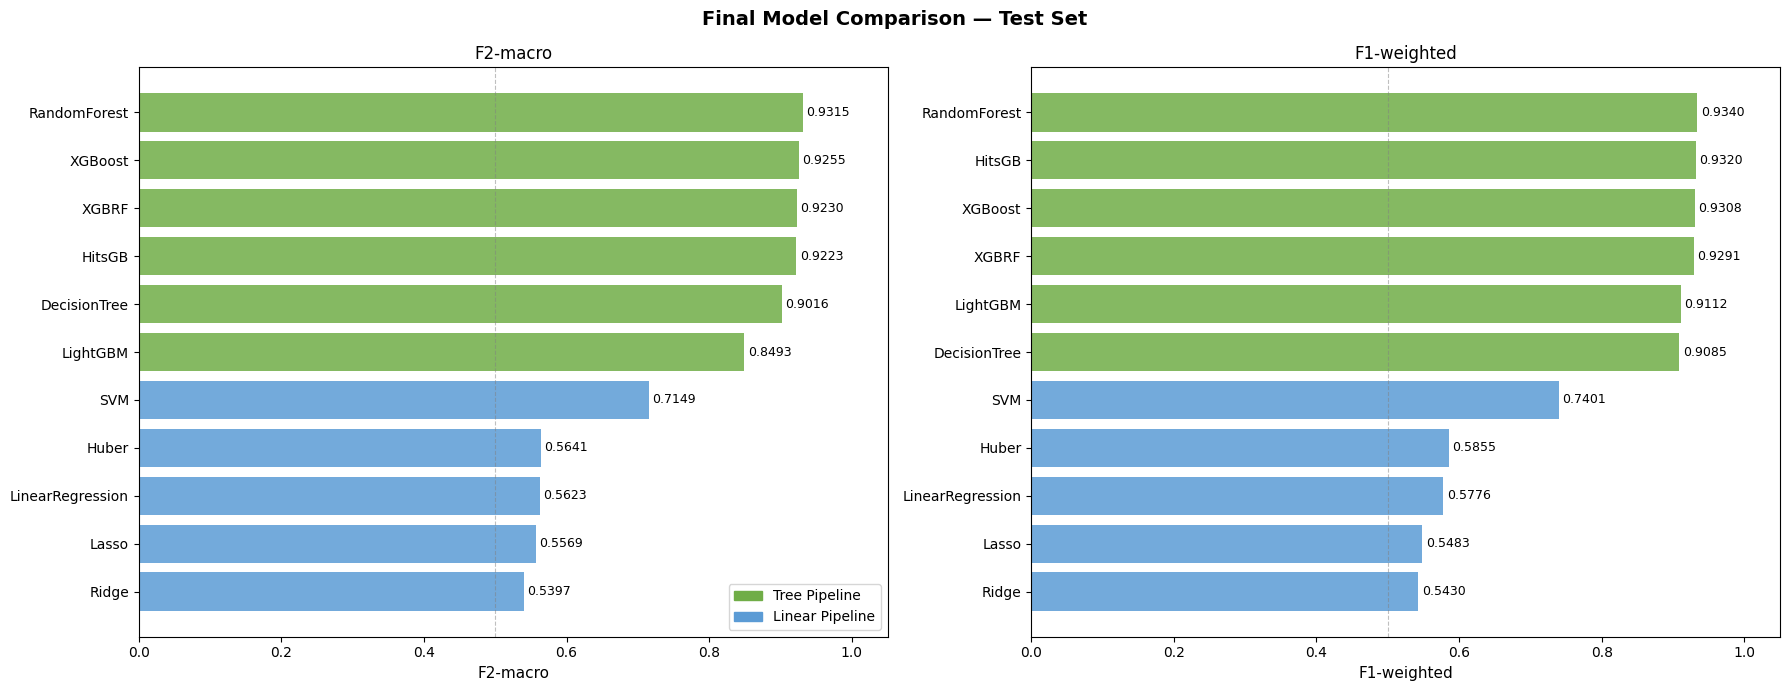

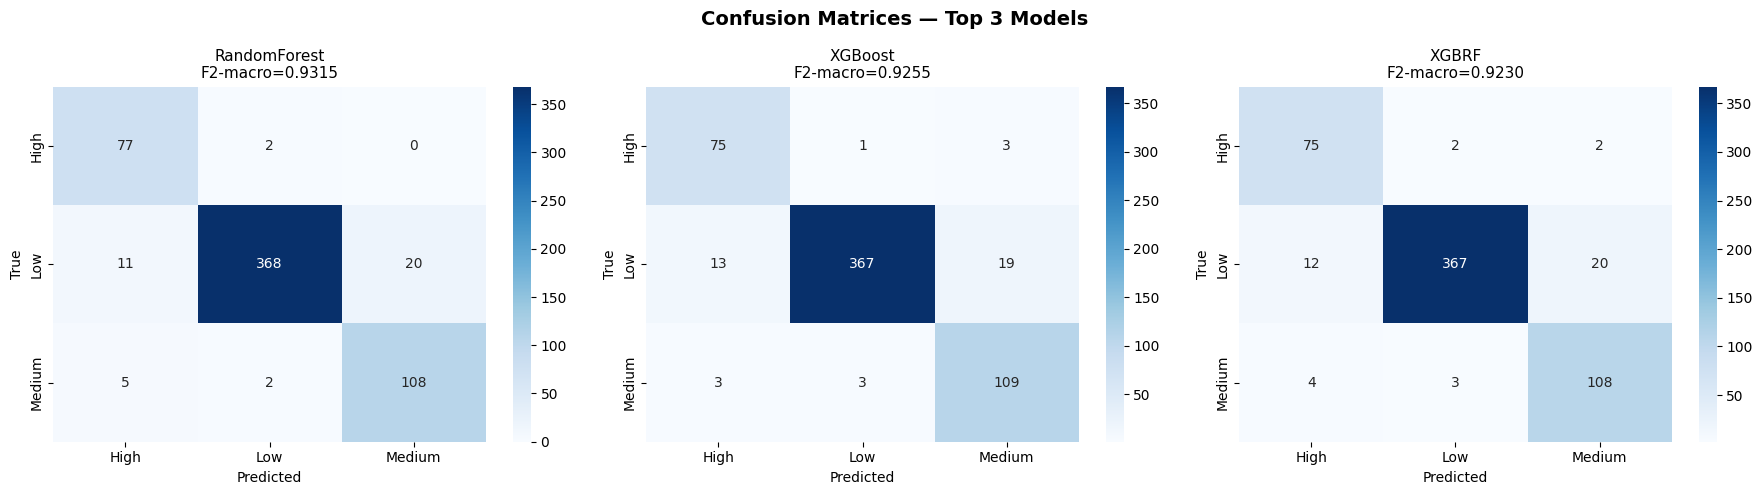

In [10]:
# ================================================================== #
# CELL 8 — Visualize: Bar Chart So Sánh
# ================================================================== #
 
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Final Model Comparison — Test Set',
             fontsize=14, fontweight='bold')
 
colors_map = {'Tree': '#70AD47', 'Linear': '#5B9BD5'}
 
for ax, metric in zip(axes, ['F2-macro', 'F1-weighted']):
    df_plot = df_results.sort_values(metric, ascending=True)
    colors  = [colors_map['Tree' if m in TREE_MODELS else 'Linear']
               for m in df_plot['Model']]
 
    bars = ax.barh(df_plot['Model'], df_plot[metric],
                   color=colors, alpha=0.85)
    ax.set_xlabel(metric, fontsize=11)
    ax.set_title(metric, fontsize=12)
    ax.set_xlim(0, 1.05)
    ax.axvline(0.5, color='gray', linestyle='--',
               linewidth=0.8, alpha=0.5)
 
    for bar, val in zip(bars, df_plot[metric]):
        ax.text(bar.get_width() + 0.005,
                bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=9)
 
from matplotlib.patches import Patch
legend = [Patch(color='#70AD47', label='Tree Pipeline'),
          Patch(color='#5B9BD5', label='Linear Pipeline')]
axes[0].legend(handles=legend, loc='lower right')
 
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'model_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()
 
 
# ================================================================== #
# CELL 9 — Confusion Matrices (Top 3 Models)
# ================================================================== #
 
top3 = df_results.head(3)['Model'].tolist()
label_names = ['High', 'Low', 'Medium']
 
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Confusion Matrices — Top 3 Models',
             fontsize=14, fontweight='bold')
 
for ax, model_name in zip(axes, top3):
    cm = np.array(detailed_metrics[model_name]['confusion_matrix'])
    sns.heatmap(
        cm, ax=ax, annot=True, fmt='d',
        cmap='Blues',
        xticklabels=label_names,
        yticklabels=label_names
    )
    f2 = detailed_metrics[model_name]['f2_macro']
    ax.set_title(f'{model_name}\nF2-macro={f2:.4f}', fontsize=11)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
 
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'confusion_matrices_top3.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [11]:
# ================================================================== #
# CELL 10 — Lưu Kết Quả
# ================================================================== #
 
# CSV
df_results.to_csv(RESULTS_DIR / 'final_metrics.csv', index=False)
df_perclass.to_csv(RESULTS_DIR / 'per_class_metrics.csv', index=False)
 
# JSON chi tiết
save_data = {}
for model_name, metrics in detailed_metrics.items():
    split_metrics = all_results[model_name]
    save_data[model_name] = {
        'train_f2_macro'   : split_metrics['train_f2_macro'],
        'train_f1_weighted': split_metrics['train_f1_weighted'],
        'test_f2_macro'    : split_metrics['test_f2_macro'],
        'test_f1_weighted' : split_metrics['test_f1_weighted'],
        'best_params'     : metrics['best_params'],
        'confusion_matrix': metrics['confusion_matrix'],
        'per_class'       : {
            cls: {
                'precision': metrics['per_class'][cls]['precision'],
                'recall'   : metrics['per_class'][cls]['recall'],
                'f1-score' : metrics['per_class'][cls]['f1-score'],
                'support'  : metrics['per_class'][cls]['support'],
            }
            for cls in ['High', 'Medium', 'Low']
        }
    }
 
with open(RESULTS_DIR / 'detailed_metrics.json', 'w') as f:
    json.dump(save_data, f, indent=2)
 
print("Results saved:")
print(f"  {RESULTS_DIR / 'final_metrics.csv'}")
print(f"  {RESULTS_DIR / 'per_class_metrics.csv'}")
print(f"  {RESULTS_DIR / 'detailed_metrics.json'}")
print(f"\nModels in {MODELS_DIR}/:")
for p in sorted(MODELS_DIR.glob('*.pkl')):
    size_mb = p.stat().st_size / 1024 / 1024
    print(f"  {p.name} ({size_mb:.1f} MB)")

Results saved:
  ../flood-forecast/results/final/final_metrics.csv
  ../flood-forecast/results/final/per_class_metrics.csv
  ../flood-forecast/results/final/detailed_metrics.json

Models in ../flood-forecast/saved_models/:
  DecisionTree.pkl (0.1 MB)
  HitsGB.pkl (1.1 MB)
  Huber.pkl (0.1 MB)
  Lasso.pkl (0.1 MB)
  LightGBM.pkl (5.7 MB)
  LinearRegression.pkl (0.1 MB)
  RandomForest.pkl (16.2 MB)
  Ridge.pkl (0.1 MB)
  SVM.pkl (1.8 MB)
  XGBRF.pkl (4.7 MB)
  XGBoost.pkl (1.6 MB)


In [12]:
# ================================================================== #
# CELL 11 — Best Model Summary
# ================================================================== #
 
best_name    = df_results.iloc[0]['Model']
best_metrics = detailed_metrics[best_name]
 
print(f"\n{'='*55}")
print(f"BEST MODEL: {best_name}")
print(f"{'='*55}")
best_splits = all_results[best_name]
print(f"  Train F2/F1: {best_splits['train_f2_macro']:.4f} / "
      f"{best_splits['train_f1_weighted']:.4f}")
print(f"  Test  F2/F1: {best_splits['test_f2_macro']:.4f} / "
      f"{best_splits['test_f1_weighted']:.4f}")
 
if best_metrics['best_params']:
    print(f"  Best params : {best_metrics['best_params']}")
 
print(f"\nPer-class performance:")
print(f"  {'Class':8s} {'Precision':>10} {'Recall':>8} "
      f"{'F1':>8} {'Support':>8}")
print(f"  {'-'*46}")
for cls in ['High', 'Medium', 'Low']:
    pc = best_metrics['per_class'][cls]
    print(f"  {cls:8s} {pc['precision']:>10.3f} {pc['recall']:>8.3f} "
          f"{pc['f1-score']:>8.3f} {pc['support']:>8.0f}")
 
print(f"\n{'='*55}")
print(f"FULL RANKING:")
print(f"{'='*55}")
print(df_results[['Rank', 'Model', 'Pipeline',
                  'Train F2-macro', 'Train F1-weighted',
                  'Test F2-macro', 'Test F1-weighted',
                  'F2 gap', 'F1 gap']]
      .to_string(index=False))
 


BEST MODEL: RandomForest
  Train F2/F1: 0.9989 / 0.9992
  Test  F2/F1: 0.9315 / 0.9340
  Best params : {'n_estimators': 400, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 0.7, 'max_depth': 35, 'class_weight': 'balanced'}

Per-class performance:
  Class     Precision   Recall       F1  Support
  ----------------------------------------------
  High          0.828    0.975    0.895       79
  Medium        0.844    0.939    0.889      115
  Low           0.989    0.922    0.955      399

FULL RANKING:
 Rank            Model Pipeline  Train F2-macro  Train F1-weighted  Test F2-macro  Test F1-weighted  F2 gap  F1 gap
    1     RandomForest     Tree          0.9989             0.9992         0.9315            0.9340  0.0674  0.0652
    2          XGBoost     Tree          0.9510             0.9546         0.9255            0.9308  0.0255  0.0238
    3            XGBRF     Tree          0.9776             0.9770         0.9230            0.9291  0.0546  0.0479
    4        